In [54]:
%load_ext autoreload
%autoreload 2

import cupy as cp
import math
import random
import matplotlib.pyplot as plt
from model.network import Network
from util.data_loader import DataLoader
from util.checkpoint_manager import CheckpointManager
from util.adamw import AdamWOptimizer
from util.evaluation_helper import EvaluationHelper

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Loading the Data

In [57]:
data_loader = DataLoader("input/training.txt", "input/validation.txt", num_merges=300)
vocabulary = data_loader.get_vocabulary()

Training BPE with 300 merges...
  merge 100/300: 'i'+'t ' -> 'it '  (vocab=165)
  merge 200/300: 'E'+'R' -> 'ER'  (vocab=265)
  merge 300/300: 'd'+'er' -> 'der'  (vocab=364)
Training data length: X=424432, Y=424432
Validation data length: X=113195, Y=113195
Vocabulary size: 364


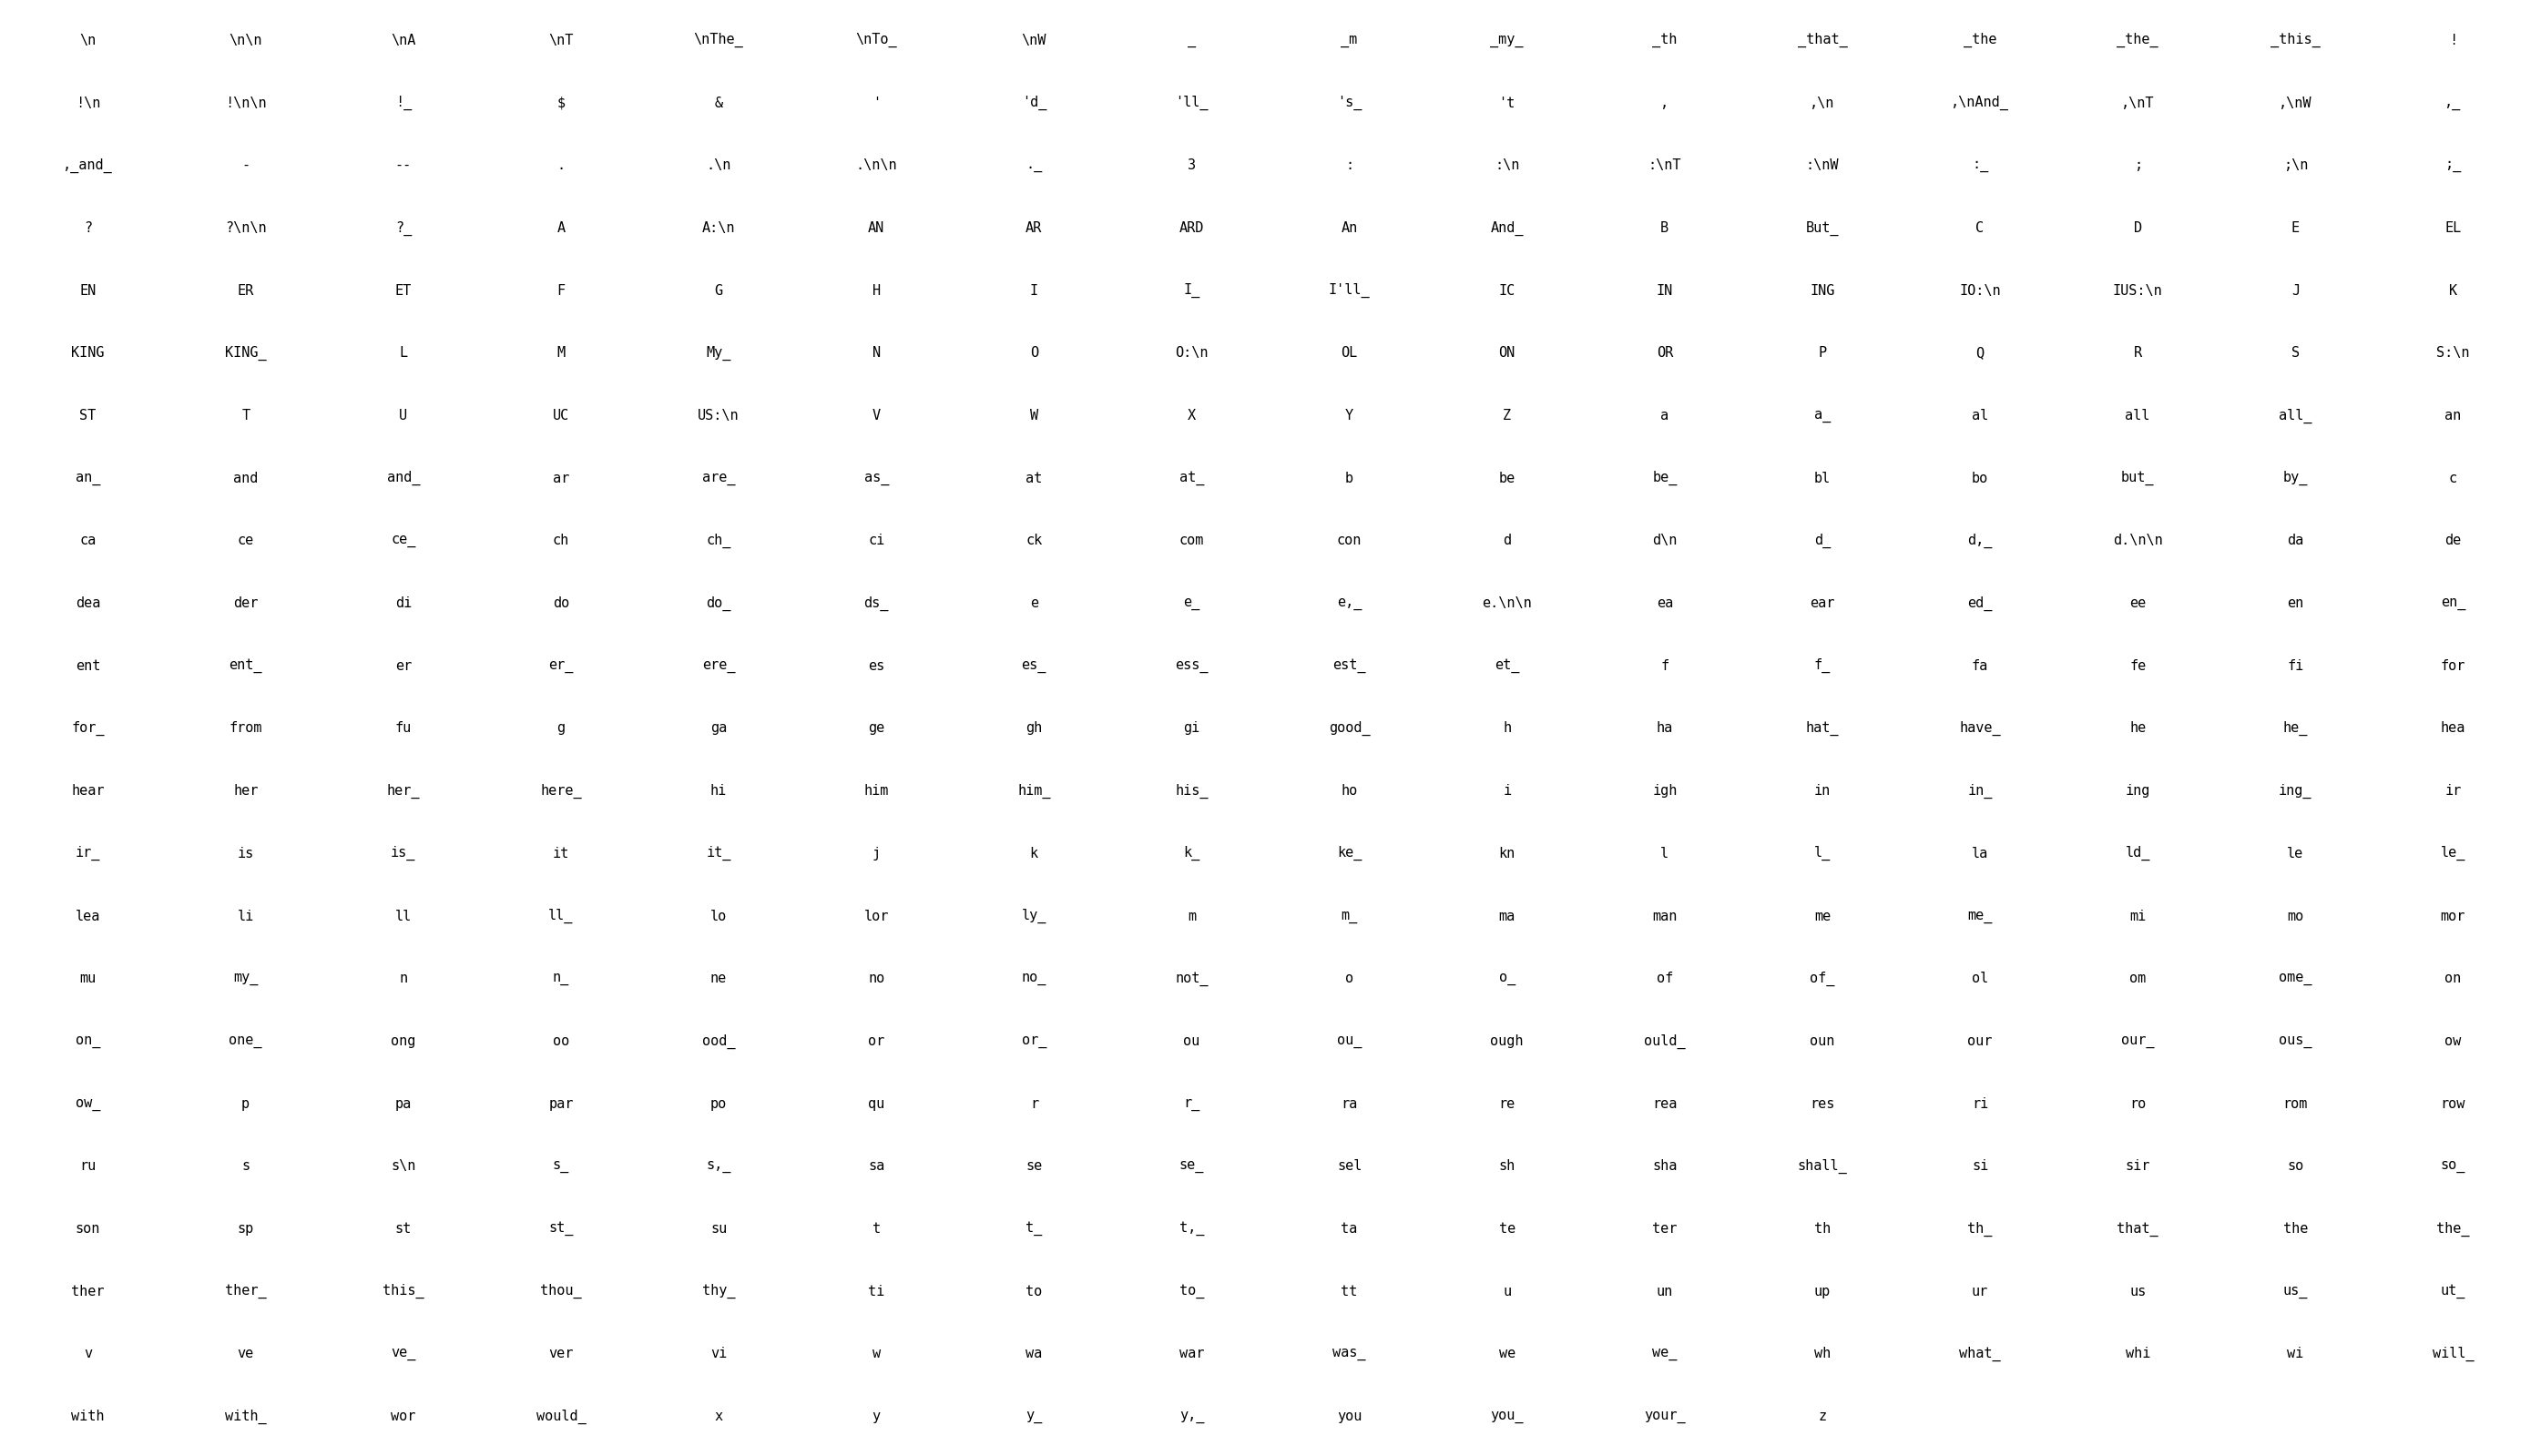

In [99]:
data_loader.plot_vocabulary()

In [59]:
x_train_indices, y_train_indices, x_test_indices, y_test_indices = data_loader.get_indices()

## Building the Model

In [56]:
embedding_dim = 128
hidden_size = 256
hidden2_size = 192

layer_definitions = [
    {"type": "Embedding", "num_embeddings": len(vocabulary), "embedding_dim": embedding_dim},
    {"type": "Recurrent", "input_size": embedding_dim, "num_neurons": hidden_size},
    {"type": "Dropout"},
    {"type": "Recurrent", "input_size": hidden_size, "num_neurons": hidden2_size},
    {"type": "Dropout"},
    {"type": "Softmax", "input_size": hidden2_size, "num_neurons": len(vocabulary)},
]

model = Network(layer_definitions=layer_definitions)
model.describe()

Network Architecture

Layer 1: EmbeddingLayer
  Embeddings Shape: (364, 128)
  Parameters: 46,592

Layer 2: RecurrentLayer
  Weights Shape: (128, 256) | State Weights Shape: (256, 256) | Biases Shape: (256,)
  Parameters: 98,560

Layer 3: DropoutLayer
  Rate: 0.2

Layer 4: RecurrentLayer
  Weights Shape: (256, 192) | State Weights Shape: (192, 192) | Biases Shape: (192,)
  Parameters: 86,208

Layer 5: DropoutLayer
  Rate: 0.2

Layer 6: SoftmaxLayer
  Weights Shape: (192, 364) | Biases Shape: (364,)
  Parameters: 70,252

Total Parameters: 301,612


## Training the Model

In [60]:
def one_hot(indices: cp.ndarray, num_classes: int) -> cp.ndarray:
    encoded = cp.zeros((indices.shape[0], num_classes), dtype=cp.float32)
    encoded[cp.arange(indices.shape[0]), indices] = 1.0
    return encoded

In [61]:
def reshape_streams(
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    max_columns: int | None = None,
 ) -> tuple[cp.ndarray, cp.ndarray]:
    usable_tokens = (x_indices.shape[0] // batch_size) * batch_size
    x = x_indices[:usable_tokens].reshape(batch_size, -1)
    y = y_indices[:usable_tokens].reshape(batch_size, -1)

    if max_columns is not None:
        x = x[:, :max_columns]
        y = y[:, :max_columns]

    return x, y

In [62]:
def evaluate(
    model: Network,
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    sequence_length: int,
    max_steps: int | None = None,
) -> float:
    x, y = reshape_streams(
        x_indices=x_indices,
        y_indices=y_indices,
        batch_size=batch_size,
        max_columns=max_steps,
    )

    model.reset_states(batch_size=batch_size, dtype=cp.float32)
    total_loss = 0.0
    total_steps = x.shape[1]

    for step in range(total_steps):
        y_prob = model.forward(x[:, step])[-1]
        y_true = one_hot(y[:, step], len(vocabulary))
        total_loss += float(model.cce_loss(y_prob, y_true).item())

        if (step + 1) % sequence_length == 0:
            model.reset_states(batch_size=batch_size, dtype=cp.float32)

    return math.exp(total_loss / total_steps)

In [63]:
def train_epoch(
    model: Network,
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    sequence_length: int,
    learning_rate: float,
    optimizer: AdamWOptimizer,
    max_steps: int | None = None,
    clip_value: float | None = None,
) -> float:
    model.set_training(True)
    x, y = reshape_streams(
        x_indices=x_indices,
        y_indices=y_indices,
        batch_size=batch_size,
        max_columns=max_steps,
    )
    model.reset_states(batch_size=batch_size, dtype=cp.float32)
    total_loss = 0.0
    total_steps = x.shape[1]

    for chunk_start in range(0, total_steps, sequence_length):
        chunk_end = min(chunk_start + sequence_length, total_steps)
        output_errors = []

        for step in range(chunk_start, chunk_end):
            y_prob = model.forward(x[:, step])[-1]
            y_true = one_hot(y[:, step], len(vocabulary))
            total_loss += float(model.cce_loss(y_prob, y_true).item())
            output_errors.append(y_prob - y_true)

        model.backward_sequence(output_errors, batch_size, clip_value=clip_value)
        optimizer.step(model, learning_rate)
        model.reset_states(batch_size=batch_size, dtype=cp.float32)

    model.set_training(False)
    return math.exp(total_loss / total_steps)


In [64]:
hyperparameters = {
    "sequence_length": 64,
    "batch_size": 64,
    "epochs": 1000,
    "train_steps_per_epoch": 4096,
    "validation_steps": 1024,
    "base_learning_rate": 1e-3,
    "min_learning_rate": 1e-6,
    "weight_decay_lambda": 2e-2,
    "beta1": 0.9,
    "beta2": 0.999,
    "epsilon": 1e-8,
    "early_stopping_patience": 150,
    "clip_value": 1.0,
    "checkpoint_interval": 50,
    "dropout_rate": 0.35
}

print(hyperparameters)

{'sequence_length': 64, 'batch_size': 64, 'epochs': 1000, 'train_steps_per_epoch': 4096, 'validation_steps': 1024, 'base_learning_rate': 0.001, 'min_learning_rate': 1e-06, 'weight_decay_lambda': 0.02, 'beta1': 0.9, 'beta2': 0.999, 'epsilon': 1e-08, 'early_stopping_patience': 150, 'clip_value': 1.0, 'checkpoint_interval': 50, 'dropout_rate': 0.35}


In [65]:
checkpoint_manager = CheckpointManager(file_name="rnn_checkpoint.pkl")
best_model, epoch_summaries, best_perplexity = checkpoint_manager.load_checkpoint()

if best_model is not None:
    model = best_model.clone()

optimizer = AdamWOptimizer(
    beta1=hyperparameters["beta1"],
    beta2=hyperparameters["beta2"],
    epsilon=hyperparameters["epsilon"],
    weight_decay=hyperparameters["weight_decay_lambda"],
)

max_available_steps = int(x_train_indices.shape[0]) // hyperparameters["batch_size"]
train_steps_per_epoch = min(hyperparameters["train_steps_per_epoch"], max_available_steps)
if train_steps_per_epoch < hyperparameters["train_steps_per_epoch"]:
    print(f"Warning: train_steps_per_epoch clamped from {hyperparameters['train_steps_per_epoch']} to {train_steps_per_epoch} (data too short after BPE compression)")

model.update_dropout_rate(hyperparameters["dropout_rate"])

total_steps = hyperparameters["epochs"] * train_steps_per_epoch
global_step = 0
epochs_without_improvement = 0

slice_size = hyperparameters["batch_size"] * train_steps_per_epoch
max_offset = int(x_train_indices.shape[0]) - slice_size
epoch_offset = len(epoch_summaries)


Loaded checkpoint, best perplexity: 21.5793


In [ ]:
for epoch in range(1, hyperparameters["epochs"] + 1):
    learning_rate = hyperparameters["min_learning_rate"] + 0.5 * (hyperparameters["base_learning_rate"] - hyperparameters["min_learning_rate"]) * (1 + math.cos(math.pi * global_step / total_steps))

    offset = random.randint(0, max_offset)
    x_slice = x_train_indices[offset : offset + slice_size]
    y_slice = y_train_indices[offset : offset + slice_size]

    train_perplexity = train_epoch(
        model=model,
        x_indices=x_slice,
        y_indices=y_slice,
        batch_size=hyperparameters["batch_size"],
        sequence_length=hyperparameters["sequence_length"],
        learning_rate=learning_rate,
        optimizer=optimizer,
        clip_value=hyperparameters["clip_value"],
    )
    test_perplexity = evaluate(
        model=model,
        x_indices=x_test_indices,
        y_indices=y_test_indices,
        batch_size=hyperparameters["batch_size"],
        sequence_length=hyperparameters["sequence_length"],
        max_steps=hyperparameters["validation_steps"],
    )

    epoch_summary = {
        "epoch": epoch + epoch_offset,
        "learning_rate": learning_rate,
        "train_perplexity": train_perplexity,
        "test_perplexity": test_perplexity,
        "regularization": train_perplexity / test_perplexity,
    }
    epoch_summaries.append(epoch_summary)

    if (epoch + epoch_offset) % 10 == 0 or epoch == 1:
        print(epoch_summary)

    if test_perplexity < best_perplexity:
        best_perplexity = test_perplexity
        best_model = model.clone()
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    global_step += train_steps_per_epoch

    if (epoch + epoch_offset) % hyperparameters["checkpoint_interval"] == 0:
        checkpoint_manager.save_checkpoint(best_model, vocabulary, epoch_summaries)

    if epochs_without_improvement >= hyperparameters["early_stopping_patience"]:
        print(f"Early stopping triggered after {epoch + epoch_offset} epochs due to no improvement.")
        break


In [ ]:
print(f"Best validation perplexity: {best_perplexity:.6f}")
checkpoint_manager.save_checkpoint(best_model, vocabulary, epoch_summaries)

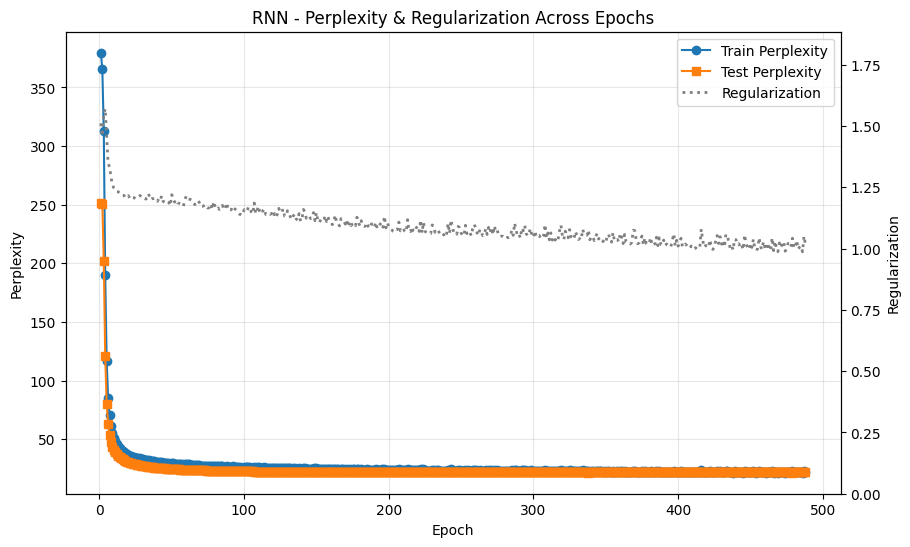

In [66]:
epochs_plot = [summary["epoch"] for summary in epoch_summaries]
train_perplexities = [summary["train_perplexity"] for summary in epoch_summaries]
test_perplexities = [summary["test_perplexity"] for summary in epoch_summaries]
regularizations = [summary["regularization"] for summary in epoch_summaries]

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(epochs_plot, train_perplexities, marker="o", label="Train Perplexity")
ax1.plot(epochs_plot, test_perplexities, marker="s", label="Test Perplexity")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Perplexity")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(epochs_plot, regularizations, color="gray", linestyle=":", linewidth=2, label="Regularization")
ax2.set_ylim(0, max(regularizations) * 1.2)
ax2.set_ylabel("Regularization")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.title("RNN - Perplexity & Regularization Across Epochs")
plt.show()

## Evaluating the Model

### Text Generation

In [113]:
eval_helper = EvaluationHelper(model=best_model, data_loader=data_loader, vocabulary=vocabulary)
generated_tokens = eval_helper.generate_text(seed_text="HAMLET", length=500, temperature=0.7)

HAMLET:
My lord and fares him to dulling lewits,
Being honour crown of God, butters of him.

POMPED:
Sir, sir.

AUFIDIUS:
Twenter, to the bones.

SICINIUS:
One straight as this,
Which he will stands in young and seal of the truth:
And when I know not hath a garlard that bord,
For you may first thered?

CAPULET:
Even in his great love sist to take house in you most
Happy his grace do not better priplied
The state of pluckful others,
Sir, my brother's troy! Have my podle. This wys;
And which we are fine of a mans hath sent to me ene
The odding some hands with one royal dore of honour.

KING LEWIS XI:
And far with the sweet proculicing and sun and him
He justace then stays his cury of justice;
And hear their soul's merry have I tellt:
How, and now you love me and like a brave of wretchend.

LUCIO:
So made a place: but I am brother:
O, I will better for a come him; I should be swords
And my father's false is Thence, I will smup to thy love:
So shall call you, the tender sight and gragers
O

### Token Frequencies

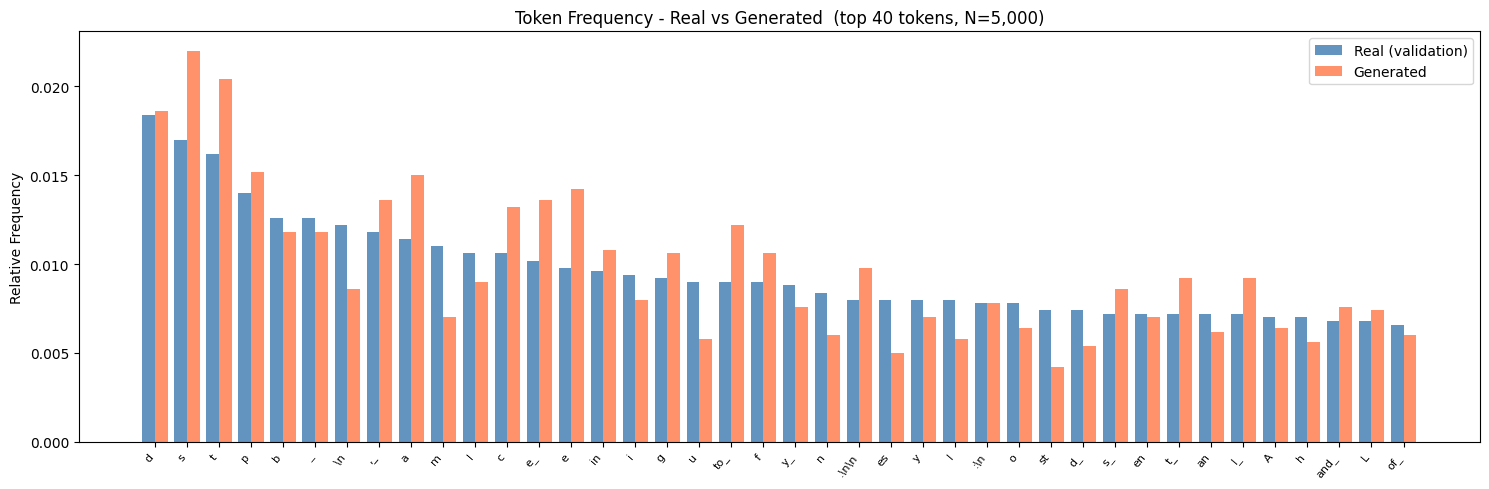

In [105]:
eval_helper.plot_token_frequencies(x_test_indices=x_test_indices)

### Embedding Spaces

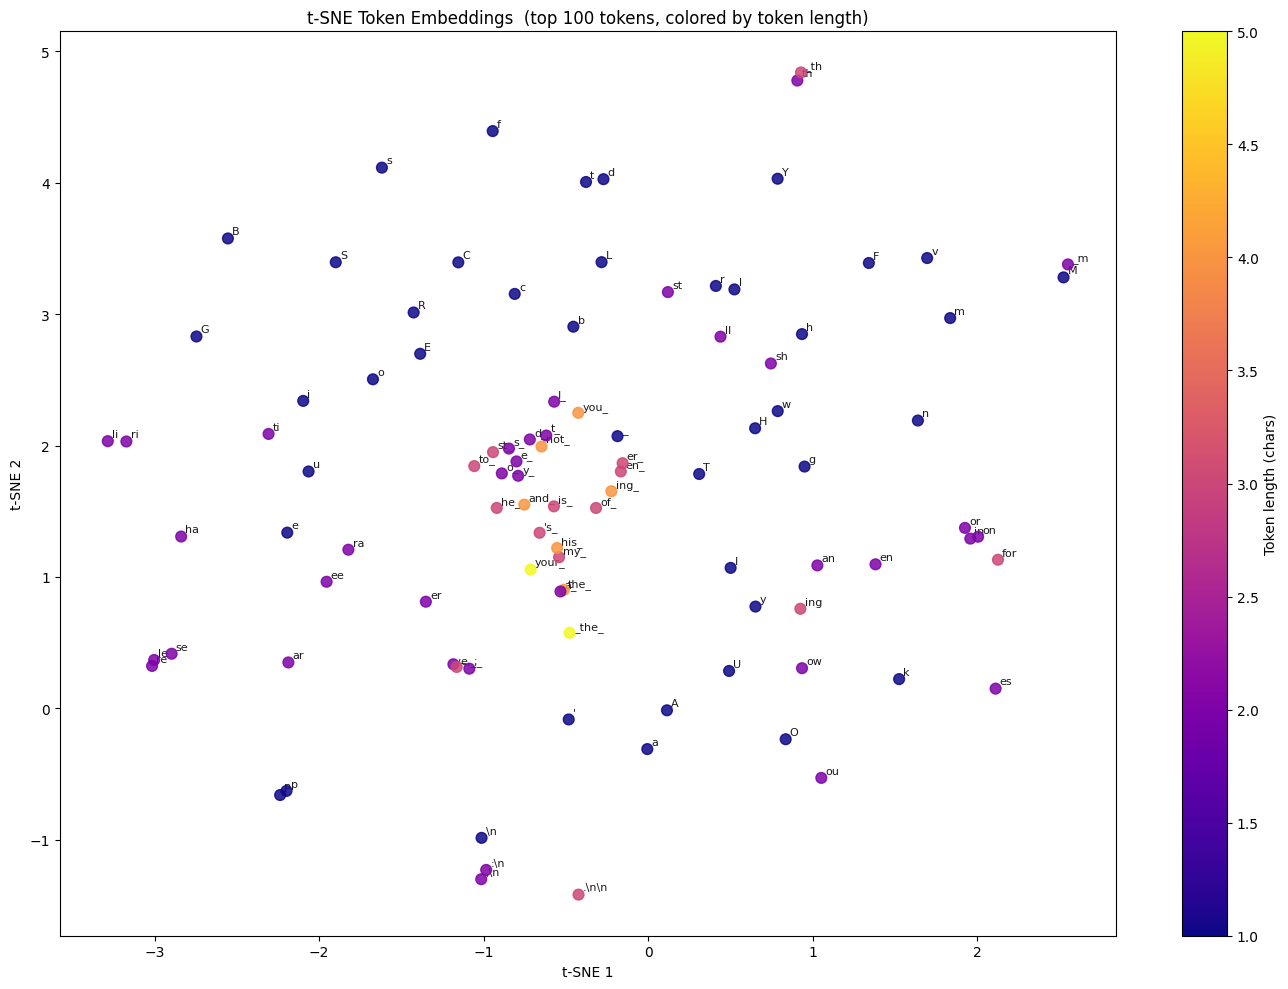

In [114]:
eval_helper.plot_embeddings_tsne(x_test_indices=x_test_indices)

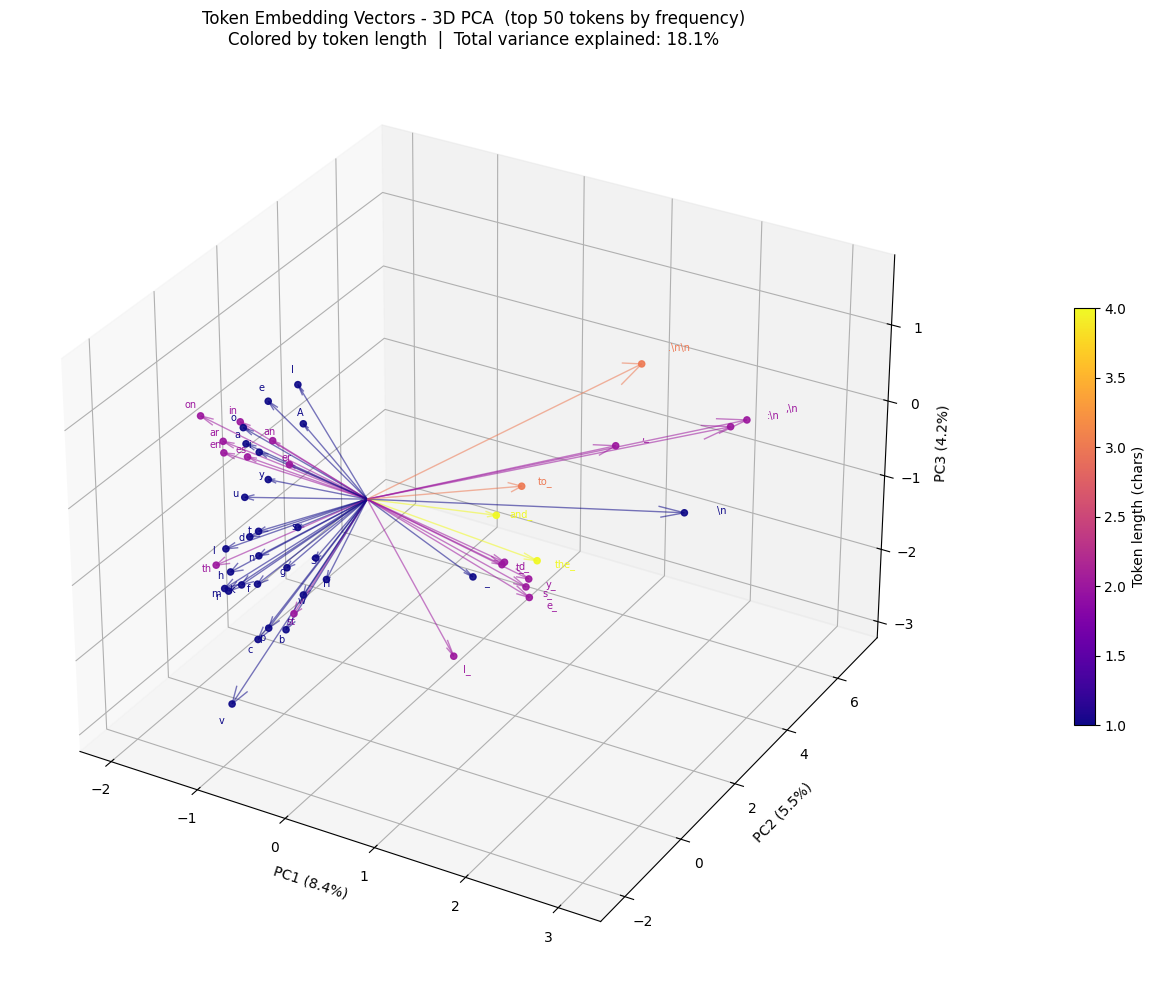

In [115]:
eval_helper.plot_embeddings_3d(x_test_indices=x_test_indices)

### Hidden State Trajectory

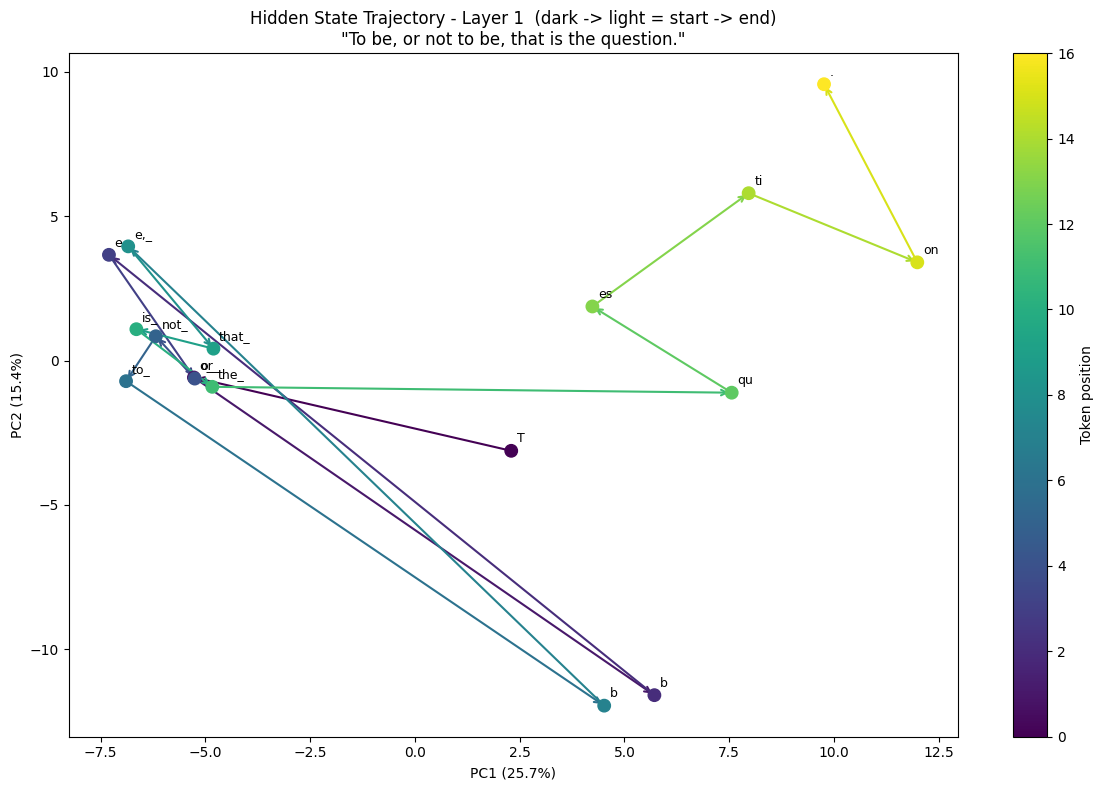

In [108]:
eval_helper.plot_hidden_state_trajectory(sentence="To be, or not to be, that is the question.")

### Temperature Sweep

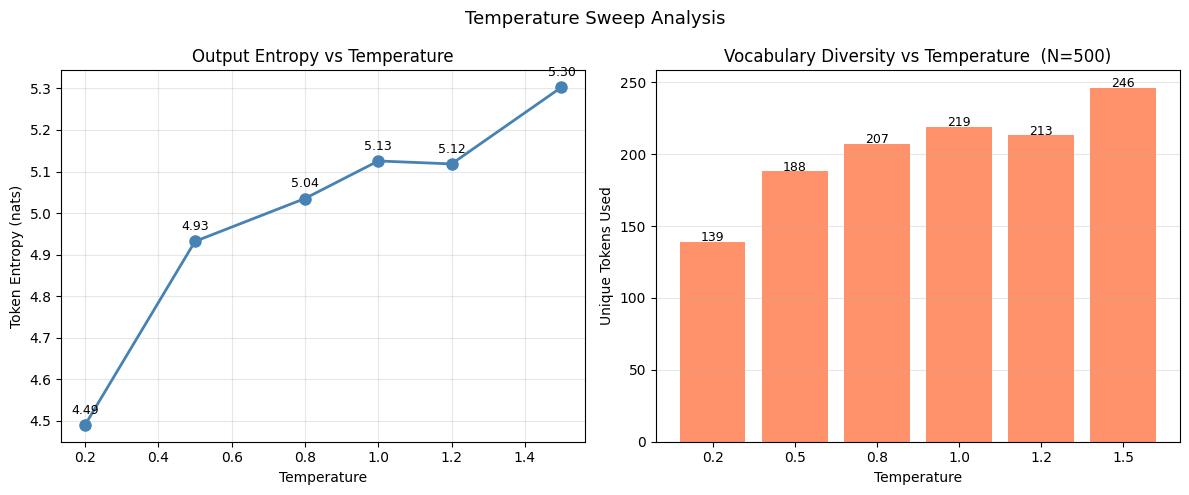

In [110]:
eval_helper.plot_temperature_sweep(seed_text="HAMLET")